# Data loading

In [77]:
import torch
from pathlib import Path

from torchvision.datasets import CelebA

#CLIP
from transformers import CLIPProcessor, CLIPModel
import numpy as np
from tqdm import tqdm

In [12]:
data_root = Path("./Celeba")

In [16]:
celeba_train = CelebA(root=data_root, split="train", download=False)
celeba_valid = CelebA(root=data_root, split="valid", download=False)
celeba_test = CelebA(root=data_root, split="test", download=False)
celeba_all = CelebA(root=data_root, split="all", download=False)

In [17]:
print(f"TRAINING SET: {len(celeba_train)}")
print(f"VALIDATION SET: {len(celeba_valid)}")
print(f"TEST SET: {len(celeba_test)}")
print(f"FULL SET: {len(celeba_all)}")

TRAINING SET: 162770
VALIDATION SET: 19867
TEST SET: 19962
FULL SET: 202599


# Metrics

In [18]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.

    """
    # Isolate the top K predictions
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

In [19]:
# --- Example Usage ---
# Suppose the model returns these indices from most to least similar:
predictions = [1, 2, 3, 4, 5]
# And we load this from our JSON for this specific source:
ground_truth = [3, 2, 1]

# Evaluate at K=1 and K=5
print("Results @ 1:", evaluate_retrieval(predictions, ground_truth, k=1))
print("Results @ 5:", evaluate_retrieval(predictions, ground_truth, k=5))

Results @ 1: {'Recall@1': 1, 'Precision@1': 1.0}
Results @ 5: {'Recall@5': 1, 'Precision@5': 0.6}


# Evaluation

In [20]:
import json

In [21]:
annotations_path = Path("celeba_evaluation.json")

with open(annotations_path, "r") as f:
    annotations = json.load(f)

len(annotations)

14

In [22]:
# `annotations` is a list of queries
# Each query is a dictionary with these keys:
# - `query`: the textual query itself
# - `ground_truth`: a dictionary of images
#
# Each element in `ground_truth` is structured as:
# {
#    idx: list[int]
# }
# `idx` is the source image that you have to use together with the `query`
# `list[int]` is the list of acceptable target images, i.e., the images
# that you should retrieve

print(annotations[0].keys())
print()
print("Query:", annotations[0]["query"])
print("Source images:", len(annotations[0]["ground_truth"].keys()))

dict_keys(['query', 'ground_truth'])

Query: +Smiling
Source images: 4786


Let's test the evaluation function. Let's simulate retrieving data for the first image / query.

In [23]:
print("Nothing retrieved:\n", evaluate_retrieval([], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved only one wrong image:\n", evaluate_retrieval([0], annotations[0]["ground_truth"]["13"], 1))
print()
print("Retrieved 10 correct images:\n", evaluate_retrieval(annotations[0]["ground_truth"]["13"][:10], annotations[0]["ground_truth"]["13"], 1))
print()
# This returns 0 and 0 because top-k is set to 1, and the first 5 images
# (by highest similarity) are incorrect. We need to jump at least to top-6 here!
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 1))
print("Retrieved 5 correct images and 5 wrong images:\n", evaluate_retrieval([0, 1, 2, 3, 4] + annotations[0]["ground_truth"]["13"][:5], annotations[0]["ground_truth"]["13"], 6))

Nothing retrieved:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved only one wrong image:
 {'Recall@1': 0, 'Precision@1': 0.0}

Retrieved 10 correct images:
 {'Recall@1': 1, 'Precision@1': 1.0}

Retrieved 5 correct images and 5 wrong images:
 {'Recall@1': 0, 'Precision@1': 0.0}
Retrieved 5 correct images and 5 wrong images:
 {'Recall@6': 1, 'Precision@6': 0.16666666666666666}


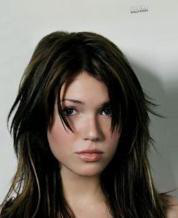

In [24]:
# This is our source image
# Basically, the `key` in the provided JSON corresponds to the
# image index. Note, however, that the key is in string format,
# so remember to convert it with `int(key)`!
celeba_test[13][0]

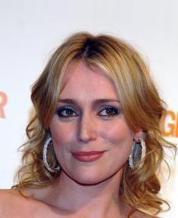

In [25]:
# This is one of the accepted matches
celeba_test[annotations[0]["ground_truth"]["13"][0]][0]

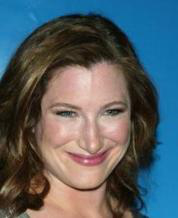

In [26]:
# This is another one of the accepted matches
celeba_test[annotations[0]["ground_truth"]["13"][1]][0]

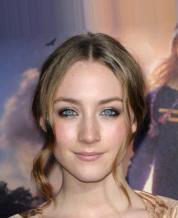

In [27]:
# And yet another one of the accepted matches
celeba_test[annotations[0]["ground_truth"]["13"][2]][0]

As you can see, all these images are pretty similar to the first one (the "source").
This is exactly what we want.
We constructed the ground truth by taking images that match the given query, with a Hamming distance of at most 2 from the source (i.e., having a perfect match for the query is impossible, so we allow some small variability on other attributes, too).

# Misc

In [34]:
# Unique index to each attribute, and inverse mapping
idx2attribute = {idx: name for idx, name in enumerate(celeba_test.attr_names)}
attribute2idx = {name: idx for idx, name in enumerate(celeba_test.attr_names)}

In [50]:
attribute2idx

{'5_o_Clock_Shadow': 0,
 'Arched_Eyebrows': 1,
 'Attractive': 2,
 'Bags_Under_Eyes': 3,
 'Bald': 4,
 'Bangs': 5,
 'Big_Lips': 6,
 'Big_Nose': 7,
 'Black_Hair': 8,
 'Blond_Hair': 9,
 'Blurry': 10,
 'Brown_Hair': 11,
 'Bushy_Eyebrows': 12,
 'Chubby': 13,
 'Double_Chin': 14,
 'Eyeglasses': 15,
 'Goatee': 16,
 'Gray_Hair': 17,
 'Heavy_Makeup': 18,
 'High_Cheekbones': 19,
 'Male': 20,
 'Mouth_Slightly_Open': 21,
 'Mustache': 22,
 'Narrow_Eyes': 23,
 'No_Beard': 24,
 'Oval_Face': 25,
 'Pale_Skin': 26,
 'Pointy_Nose': 27,
 'Receding_Hairline': 28,
 'Rosy_Cheeks': 29,
 'Sideburns': 30,
 'Smiling': 31,
 'Straight_Hair': 32,
 'Wavy_Hair': 33,
 'Wearing_Earrings': 34,
 'Wearing_Hat': 35,
 'Wearing_Lipstick': 36,
 'Wearing_Necklace': 37,
 'Wearing_Necktie': 38,
 'Young': 39,
 '': 40}

In [51]:
idx2attribute[4]

'Bald'

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x7F7C6C30F750>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))
tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1])


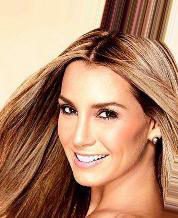

In [42]:
print(celeba_all[0])
print(celeba_all[0][1])
celeba_all[0][0]



In [ ]:
def matches(query, split=celeba_all):
    """
        Takes an attribute query in the form query[i] = +/-Attribute and returns the images that match it
    """

    considered_attributes = []
    n_matches = 0
    matches = []
    is_candidate = False

    for element in query:
        if element[0] == '+':
            considered_attributes.append([attribute2idx[element[1:]], 1])
        elif element[0] == '-':
            considered_attributes.append([attribute2idx[element[1:]], 0])
        else:
            print("Query formulation error")
            return

    print(considered_attributes)

    
    for individual in split:
        is_candidate = False
        for element in considered_attributes:
            if individual[1][element[0]] != element[1]:
                is_candidate = False
                break
            is_candidate = True
        if is_candidate:
            n_matches += 1
            matches.append(individual)

    return n_matches, matches

In [76]:
matches(["+Bald", "+No_Beard"], celeba_test)

[[4, 1], [24, 1]]


(253,
 [(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
           1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
           1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
           1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
           1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0])),
  (<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218>,
   tensor([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 

In [30]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/home/dfrailis/anaconda3/lib/python3.13/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [79]:
#CREATION OF THE OFFLINE VISUAL FEATURE DATABASE


all_features = []

model.eval()

with torch.no_grad():
    for idx in tqdm(range(10)):
        image = celeba_test[idx][0]

        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        image_features = model.get_image_features(**inputs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        all_features.append(image_features.squeeze().cpu().numpy())

all_features = np.stack(all_features)

np.save("celeba_visual_features.npz", features=all_features)

100%|██████████| 10/10 [00:02<00:00,  4.15it/s]


TypeError: save() got an unexpected keyword argument 'features'